<div dir="rtl" style="text-align:right">

# المحاضرة 2 — الـ Sampling ومعماريّات الاستقبال (IF مقابل Direct RF)

## أهداف المحاضرة
1. تفهم **أخذ العيّنات (sampling)**، نظرية **Nyquist**، الـ **aliasing**، ومناطق Nyquist و**الطيّ (folding)**.
2. تُميّز بين معماريّتَي الاستقبال: **IF (superheterodyne)** و**Direct RF Sampling**.
3. تعرف كيف يُخطَّط للترددات في كلٍّ منهما: اختيار الـ LO والـ IF مقابل معدل العيّنات ومناطق Nyquist والطيّ (folding) المتعمّد.
4. تدرك أثر **التكميم (quantization)** و**الرجفة الزمنية (jitter)** في محوّل ADC حقيقي.

</div>

<div dir="rtl" style="text-align:right">

## 1. أساسيات أخذ العيّنات ونظرية Nyquist

الإشارة في العالم الحقيقي **متصلة (continuous)**: لها قيمة في كل لحظة، لكن الحاسوب لا يفهم إلا أرقاماً منفصلة. لذا يأخذ محوّل **ADC (Analog-to-Digital Converter)** «لقطة» لقيمة الجهد كل فترة زمنية ثابتة — تماماً كما يلتقط الفيلم صوراً متتابعة ليحاكي الحركة. كل لقطة **عيّنة (sample)**، وعددها في الثانية هو **معدل أخذ العيّنات (sample rate, `fs`)**.

السؤال الجوهري: **كم عيّنة في الثانية تكفي لالتقاط الإشارة دون فقدان معلومة؟**

</div>

<div dir="rtl" style="text-align:right">

### نظرية Nyquist

لتمثيل إشارة أعلى تردد فيها `fmax` تمثيلاً كاملاً في المنطقة الأولى، يجب أن يكون:

<div dir="ltr" style="text-align:left">

$$ f_s > 2 \cdot f_{max} $$

</div>

القيمة `fs/2` هي **تردد Nyquist**. أي تردد يتجاوزها «ينطوي (folds)» ويظهر كأنه تردد أقل — وهذا هو الـ **aliasing**. (وسنرى لاحقاً أن الإشارات النطاقية (bandpass) تحتاج فقط `fs > 2·BW`، لا `2·fmax`.)

</div>

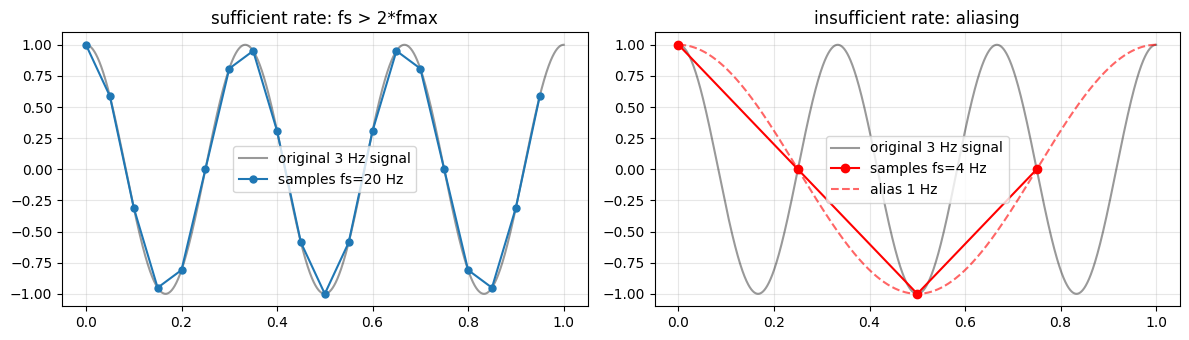

expected alias frequency = 1.0 Hz


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# high-resolution real sinusoid (pretend it is "continuous")
f0 = 3.0                      # signal frequency (Hz)
t_cont = np.linspace(0, 1, 4000)
x_cont = np.cos(2*np.pi*f0*t_cont)

# sample at a sufficient rate (fs = 20 Hz > 2*f0)
fs_ok = 20.0
t_ok = np.arange(0, 1, 1/fs_ok)
x_ok = np.cos(2*np.pi*f0*t_ok)

# sample at an insufficient rate (fs = 4 Hz < 2*f0) -> aliasing
fs_bad = 4.0
t_bad = np.arange(0, 1, 1/fs_bad)
x_bad = np.cos(2*np.pi*f0*t_bad)

fig, ax = plt.subplots(1, 2, figsize=(12,3.5))
ax[0].plot(t_cont, x_cont, 'k', alpha=0.4, label='original 3 Hz signal')
ax[0].plot(t_ok, x_ok, 'o-', ms=5, label=f'samples fs={fs_ok:.0f} Hz')
ax[0].set_title("sufficient rate: fs > 2*fmax"); ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(t_cont, x_cont, 'k', alpha=0.4, label='original 3 Hz signal')
ax[1].plot(t_bad, x_bad, 'o-', ms=6, color='r', label=f'samples fs={fs_bad:.0f} Hz')
# alias frequency: |f0 - fs| = |3-4| = 1 Hz
ax[1].plot(t_cont, np.cos(2*np.pi*1.0*t_cont), 'r--', alpha=0.6, label='alias 1 Hz')
ax[1].set_title("insufficient rate: aliasing"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("expected alias frequency =", abs(f0 - fs_bad), "Hz")


<div dir="rtl" style="text-align:right">

في اللوحة اليمنى، العيّنات الحمراء (بمعدل 4 Hz) تتطابق تماماً مع موجة **1 Hz** وهمية، رغم أن الإشارة الأصلية 3 Hz. هذا هو الـ aliasing: المعلومة الأصلية «تنكّرت» في هيئة تردد أقل. القاعدة العامة لتردد الـ alias:

<div dir="ltr" style="text-align:left">

$$ f_{alias} = |f_0 - k \cdot f_s| \quad \text{لأقرب عدد صحيح } k. $$

</div>

</div>

<div dir="rtl" style="text-align:right">

### مناطق Nyquist والطيّ (folding)

عند أخذ العيّنات بمعدل `Fs` ينقسم محور التردد إلى **مناطق Nyquist** عرض كلٍّ منها `Fs/2`. أي إشارة في منطقة أعلى **تنطوي (folds)** إلى المنطقة الأولى `[0, Fs/2]`، والمناطق الزوجية تظهر **معكوسة (mirrored)**. فهم هذه البنية مفتاحٌ لِما يلي: مستقبِل الـ IF **يتجنّب** الطيّ بمرشّح تناظري، ومستقبِل الـ Direct RF **يستغلّه عمداً**.

</div>

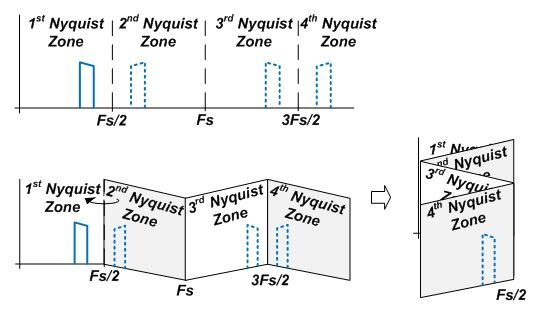

In [2]:
from IPython.display import Image
# Nyquist-zone folding (saved figure)
Image("nyquistFolding.png")

<div dir="rtl" style="text-align:right">

## 2. طريقتان لبناء الراديو

إشارتنا حول **2 GHz** (القنوات 1.955–2.045 GHz). كيف يلتقطها المستقبِل رقمياً؟ معماريّتان شائعتان:

- **(1) IF (heterodyne / superheterodyne):** مضخّم منخفض الضوضاء **LNA (Low-Noise Amplifier)** ثم **خلّاط (Mixer)** مع مذبذب محلّي **LO (Local Oscillator)** يُنزل الـ RF إلى تردد وسيط **IF (Intermediate Frequency)** منخفض، ثم ADC بطيء نسبياً.
- **(2) Direct RF Sampling:** هوائي → مرشّح → LNA → **ADC** سريع يأخذ العيّنات من الـ RF مباشرة، والباقي رقمي عبر **Digital Down Conversion (DDC)**.

المخطّط التالي يقارن السلسلتين:

</div>

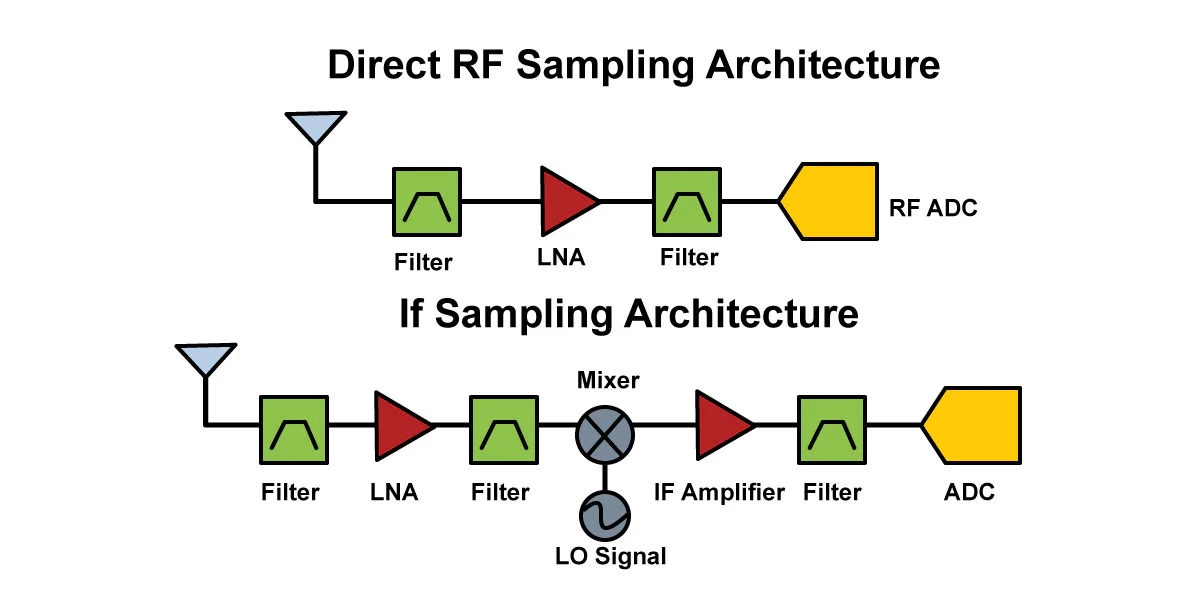

In [3]:
from IPython.display import Image
# two receiver architectures (saved figure)
Image("DIRECTvsIF.png")

<div dir="rtl" style="text-align:right">

### (1) مستقبِل الـ IF: الطيف خطوة بخطوة

نختار الـ LO بحيث `f_IF = |f_RF − f_LO|`. لقناتنا (RF = 2.0 GHz): LO = 1.94 GHz → **IF = 60 MHz**، ثم ADC عند 250 MSPS. يتتبّع الرسم الطيف عبر السلسلة: كيف يُنزل الخلط الإشارة، ولماذا يزيل **المرشّح التمهيدي (preselector)** التردد الصوري، ولماذا **مرشّح الـ IF** حرِج قبل الـ ADC (وإلا انطوى تداخل 190 MHz فوق الإشارة).

</div>

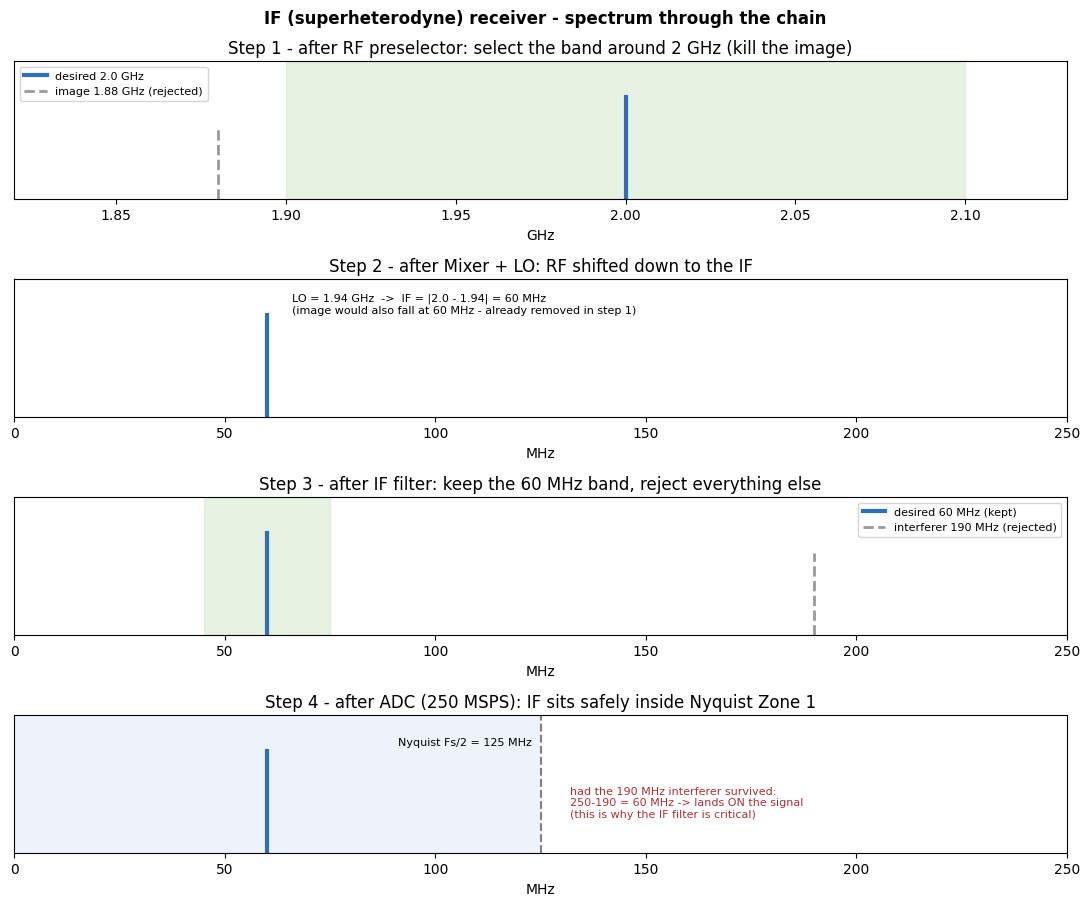

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

BLUE, RED, GREEN, PANEL = '#2c6fbb', '#c0392b', '#d6ead0', '#eef3fb'


def sig(ax, f, h=1, c=BLUE, ls='-', lw=3, label=None):
    ax.plot([f, f], [0, h], color=c, ls=ls, lw=lw, label=label)


def flow_bar(ax, steps, title="Frequency planning"):
    """Thin horizontal signal-flow bar shared by both architectures."""
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    n = len(steps)
    w = 0.86 / n
    gap = 0.14 / max(n - 1, 1)
    x = 0.0
    for i, (text, kind) in enumerate(steps):
        face = GREEN if kind == 'out' else PANEL
        edge = BLUE if kind != 'out' else '#4a8c3f'
        ax.add_patch(FancyBboxPatch(
            (x, 0.18), w, 0.52,
            boxstyle="round,pad=0.012,rounding_size=0.02",
            linewidth=1.2, edgecolor=edge, facecolor=face,
            transform=ax.transData, clip_on=False))
        ax.text(x + w / 2, 0.44, text, ha='center', va='center',
                fontsize=8.5, linespacing=1.35)
        if i < n - 1:
            ax.annotate('', xy=(x + w + gap, 0.44), xytext=(x + w, 0.44),
                        arrowprops=dict(arrowstyle='-|>', color='0.35', lw=1.4))
        x += w + gap
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)


def fs_axis(ax, ticks):
    """Label Nyquist-zone boundaries as multiples of Fs on a top axis."""
    top = ax.secondary_xaxis('top')
    top.set_xticks([t for t, _ in ticks])
    top.set_xticklabels([lbl for _, lbl in ticks], fontsize=8.5, color='0.35')
    top.tick_params(length=3, colors='0.6')
    for s in top.spines.values():
        s.set_visible(False)
    ax.set_title(ax.get_title(), pad=20)


fig, ax = plt.subplots(6, 1, figsize=(11, 12.6),
                       gridspec_kw=dict(height_ratios=[1, 1, 1, 1, 1, 0.55]))

# ----------------------------------------------------------
# Step 1 - RF preselector
# ----------------------------------------------------------
a = ax[0]
a.axvspan(1.95, 2.05, color=GREEN, alpha=0.55)
sig(a, 2.00, 1.0, BLUE, label='Desired (2.00 GHz)')
sig(a, 1.88, 0.85, RED, '--', 2, label='Image frequency (1.88 GHz)')
sig(a, 1.00, 0.70, '0.5', '--', 2, label='Strong blocker (1.00 GHz)')
a.set_xlim(0.8, 2.15)
a.set_ylim(0, 1.35)
a.set_yticks([])
a.legend(fontsize=8)
a.set_title("Step 1 - RF preselector: pass only the desired RF channel")
a.set_xlabel("GHz")

# ----------------------------------------------------------
# Step 2 - Mixer
# ----------------------------------------------------------
b = ax[1]
sig(b, 60, 1.0, BLUE, label='Desired IF = 60 MHz')
b.annotate(
    "LO = 1.94 GHz\n"
    "Desired: |2.00-1.94| = 60 MHz\n"
    "Image: |1.88-1.94| = 60 MHz\n"
    "(image already removed)",
    (72, 0.78), fontsize=8)
b.set_xlim(0, 250)
b.set_ylim(0, 1.35)
b.set_yticks([])
b.set_xlabel("MHz")
b.set_title("Step 2 - Mixer: RF translated to IF")
b.legend(fontsize=8)

# ----------------------------------------------------------
# Step 3 - IF filter
# ----------------------------------------------------------
c = ax[2]
c.axvspan(45, 75, color=GREEN, alpha=0.55)
sig(c, 60, 1.0, BLUE, label='Desired IF')
sig(c, 20, 0.45, '0.6', '--', 2)
sig(c, 150, 0.55, '0.6', '--', 2)
sig(c, 210, 0.40, '0.6', '--', 2, label='Other mixer products')
c.set_xlim(0, 250)
c.set_ylim(0, 1.35)
c.set_yticks([])
c.set_xlabel("MHz")
c.legend(fontsize=8)
c.set_title("Step 3 - IF filter: keep only the desired IF")

# ----------------------------------------------------------
# Step 4 - Nyquist zone planning (NEW)
# ----------------------------------------------------------
n = ax[3]
FS = 250.0
n.axvspan(0, FS / 2, color=GREEN, alpha=0.55)
n.axvspan(FS / 2, FS, color='0.92')
n.axvline(FS / 2, color='0.4', ls='--')
n.text(FS / 4, 1.20, "Zone 1", ha='center', fontsize=9, fontweight='bold')
n.text(3 * FS / 4, 1.20, "Zone 2", ha='center', fontsize=9, color='0.45')
sig(n, 60, 1.0, BLUE)
n.text(60, 1.04, "IF = 60 MHz", ha='center', fontsize=8.5, color=BLUE)
n.text(140, 0.52,
       "Fs = 250 MSPS\nIF = 60 MHz sits comfortably\ninside Zone 1 - no aliasing",
       fontsize=8.5,
       bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='0.7'))
n.set_xlim(0, FS)
n.set_ylim(0, 1.35)
n.set_yticks([])
n.set_xticks([0, 60, 125, 250])
n.set_xlabel("MHz")
n.set_title("Step 4 - Nyquist zone planning: choose LO so the IF lands inside Zone 1")
fs_axis(n, [(0, "0"), (FS / 2, "Fs/2"), (FS, "Fs")])

# ----------------------------------------------------------
# Step 5 - ADC
# ----------------------------------------------------------
d = ax[4]
d.axvspan(0, 125, color=PANEL)
d.axvline(125, color='0.5', ls='--')
sig(d, 60, 1.0, BLUE, label='Sampled IF')
d.annotate("Fs = 250 MSPS\nNyquist = 125 MHz", (123, 1.02), fontsize=8, ha='right')
d.set_xlim(0, 250)
d.set_ylim(0, 1.35)
d.set_yticks([])
d.set_xlabel("MHz")
d.legend(fontsize=8)
d.set_title("Step 5 - ADC: IF sampled in Nyquist Zone 1")
fs_axis(d, [(0, "0"), (125, "Fs/2"), (250, "Fs")])

# ----------------------------------------------------------
# Frequency-planning bar
# ----------------------------------------------------------
flow_bar(ax[5], [
    ("RF\n2.00 GHz", 'in'),
    ("Mixer\nLO = 1.94 GHz", 'mid'),
    ("IF\n60 MHz", 'mid'),
    ("ADC\nFs = 250 MSPS", 'mid'),
    ("Digital IF\n60 MHz (Zone 1)", 'out'),
], title="Frequency planning - analog mixing places the signal inside Zone 1 before sampling")

plt.suptitle("Superheterodyne Receiver", fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

<div dir="rtl" style="text-align:right">

### (2) مستقبِل Direct RF Sampling: الطيف خطوة بخطوة

لا خلّاط؛ الـ ADC يأخذ عيّنات من الـ RF مباشرة، ومعدل العيّنات هو **خطة الترددات**. عند `Fs = 1.5 GSPS` تقع إشارتنا (2.0 GHz) في **Zone 3** وتنطوي **عمداً** إلى **500 MHz**، ثم يُنزلها الـ DDC إلى baseband. يتتبّع الرسم الطيف عبر السلسلة ويُظهر لماذا **المرشّح التمهيدي RF ضروري** هنا.

</div>

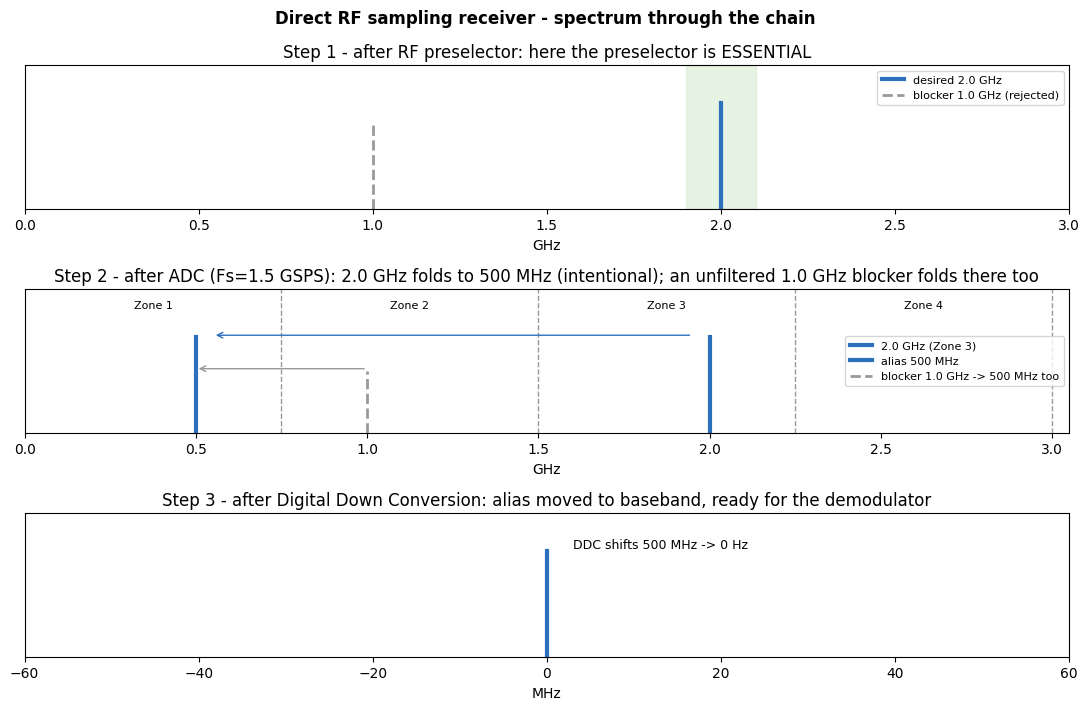

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

BLUE, RED, GREEN, PANEL = '#2c6fbb', '#c0392b', '#d6ead0', '#eef3fb'


def sig(ax, f, h=1, c=BLUE, ls='-', lw=3, label=None):
    ax.plot([f, f], [0, h], color=c, ls=ls, lw=lw, label=label)


def flow_bar(ax, steps, title="Frequency planning"):
    """Thin horizontal signal-flow bar shared by both architectures."""
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    n = len(steps)
    w = 0.86 / n
    gap = 0.14 / max(n - 1, 1)
    x = 0.0
    for i, (text, kind) in enumerate(steps):
        face = GREEN if kind == 'out' else PANEL
        edge = '#4a8c3f' if kind == 'out' else BLUE
        ax.add_patch(FancyBboxPatch(
            (x, 0.18), w, 0.52,
            boxstyle="round,pad=0.012,rounding_size=0.02",
            linewidth=1.2, edgecolor=edge, facecolor=face,
            transform=ax.transData, clip_on=False))
        ax.text(x + w / 2, 0.44, text, ha='center', va='center',
                fontsize=8.5, linespacing=1.35)
        if i < n - 1:
            ax.annotate('', xy=(x + w + gap, 0.44), xytext=(x + w, 0.44),
                        arrowprops=dict(arrowstyle='-|>', color='0.35', lw=1.4))
        x += w + gap
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)


def fs_axis(ax, ticks):
    """Label Nyquist-zone boundaries as multiples of Fs on a top axis."""
    top = ax.secondary_xaxis('top')
    top.set_xticks([t for t, _ in ticks])
    top.set_xticklabels([lbl for _, lbl in ticks], fontsize=8.5, color='0.35')
    top.tick_params(length=3, colors='0.6')
    for s in top.spines.values():
        s.set_visible(False)
    ax.set_title(ax.get_title(), pad=20)


FS = 1.5          # GSPS
NYQ = FS / 2      # 0.75 GHz


def alias(f, fs=FS):
    """Fold an RF frequency into Nyquist Zone 1."""
    r = f % fs
    return r if r <= fs / 2 else fs - r


fig, ax = plt.subplots(5, 1, figsize=(11, 11.0),
                       gridspec_kw=dict(height_ratios=[1, 1.25, 1, 1, 0.55]))

# ----------------------------------------------------------
# Step 1 - RF filter
# ----------------------------------------------------------
a = ax[0]
a.axvspan(1.95, 2.05, color=GREEN, alpha=0.55)
sig(a, 2.00, 1.0, BLUE, label='Desired (2.00 GHz)')
sig(a, 1.88, 0.85, RED, '--', 2, label='Former image frequency')
sig(a, 1.00, 0.70, '0.5', '--', 2, label='Strong blocker')
a.set_xlim(0.8, 2.15)
a.set_ylim(0, 1.35)
a.set_yticks([])
a.set_xlabel("GHz")
a.legend(fontsize=8)
a.set_title(
    "Step 1 - RF filter: reduce out-of-band energy before the ADC\n"
    "(no analog mixer -> no image-frequency problem)")

# ----------------------------------------------------------
# Step 2 - Nyquist zone planning (NEW - full zone map)
# ----------------------------------------------------------
b = ax[1]
for k in range(4):
    b.axvspan(k * NYQ, (k + 1) * NYQ,
              color=GREEN if k == 0 else ('0.94' if k % 2 else '0.88'),
              alpha=0.55 if k == 0 else 1.0, zorder=0)
for x in [0.75, 1.5, 2.25]:
    b.axvline(x, color='0.55', ls='--', zorder=1)

for k, t in enumerate(["Zone 1", "Zone 2", "Zone 3", "Zone 4"]):
    b.text(NYQ / 2 + NYQ * k, 1.40, t, ha='center', fontsize=9,
           fontweight='bold' if k == 0 else 'normal',
           color='k' if k == 0 else '0.45')

# desired 2.00 GHz -> 500 MHz
sig(b, 2.00, 1.05, BLUE)
sig(b, alias(2.00), 1.05, BLUE)
b.annotate('', xy=(alias(2.00), 1.08), xytext=(2.00, 1.08),
           arrowprops=dict(arrowstyle='-|>', color=BLUE, lw=1.4))
b.text(1.25, 1.14, "2.00 GHz -> 500 MHz", ha='center', fontsize=8, color=BLUE)

# former image 1.88 GHz -> 380 MHz
sig(b, 1.88, 0.85, RED, '--', 2)
sig(b, alias(1.88), 0.85, RED, '--', 2)
b.annotate('', xy=(alias(1.88), 0.88), xytext=(1.88, 0.88),
           arrowprops=dict(arrowstyle='-|>', color=RED, lw=1.2))
b.text(1.13, 0.92, "1.88 GHz -> 380 MHz", ha='center', fontsize=8, color=RED)

# blocker 1.00 GHz -> 500 MHz (lands on top of the desired signal)
sig(b, 1.00, 0.62, '0.5', '--', 2)
sig(b, alias(1.00), 0.62, '0.5', '--', 2)
b.annotate('', xy=(alias(1.00), 0.65), xytext=(1.00, 0.65),
           arrowprops=dict(arrowstyle='-|>', color='0.5', lw=1.2))
b.text(0.75, 0.69, "1.00 GHz -> 500 MHz", ha='center', fontsize=8, color='0.35')

b.text(2.31, 0.98,
       "Fs = 1.5 GSPS\nFs/2 = 750 MHz\nFs chosen so that 2 GHz\nfolds onto 500 MHz",
       fontsize=8.5, va='top',
       bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='0.7'))

b.set_xlim(0, 3.05)
b.set_ylim(0, 1.55)
b.set_yticks([])
b.set_xticks([0, 0.5, 0.75, 1.5, 2.25, 3.0])
b.set_xlabel("GHz")
b.set_title("Step 2 - Nyquist zone planning: choose Fs so the RF aliases where you want it")
fs_axis(b, [(0, "0"), (0.75, "Fs/2"), (1.5, "Fs"), (2.25, "3Fs/2"), (3.0, "2Fs")])

# ----------------------------------------------------------
# Step 3 - ADC output (digital spectrum, Zone 1 only)
# ----------------------------------------------------------
c = ax[2]
c.axvspan(0, 750, color=PANEL)
c.axvline(750, color='0.5', ls='--')
sig(c, 500, 1.0, BLUE, label='Desired signal at digital IF = 500 MHz')
sig(c, 500, 0.62, '0.5', '--', 2, label='Blocker alias (falls on 500 MHz)')
sig(c, 380, 0.85, RED, '--', 2, label='1.88 GHz alias at 380 MHz')
c.annotate("Fs = 1.5 GSPS\nFs/2 = 750 MHz", (745, 1.02), fontsize=8, ha='right')
c.set_xlim(0, 800)
c.set_ylim(0, 1.35)
c.set_yticks([])
c.set_xticks([0, 380, 500, 750])
c.set_xlabel("MHz")
c.legend(fontsize=8, loc='upper left')
c.set_title("Step 3 - ADC output: everything is now inside Nyquist Zone 1")
fs_axis(c, [(0, "0"), (750, "Fs/2")])

# ----------------------------------------------------------
# Step 4 - DDC
# ----------------------------------------------------------
d = ax[3]
sig(d, 0, 1.0, BLUE, label='Desired baseband')
d.annotate("DDC shifts\n500 MHz -> DC", (5, 1.02), fontsize=9)
d.set_xlim(-60, 60)
d.set_ylim(0, 1.35)
d.set_yticks([])
d.set_xlabel("MHz")
d.legend(fontsize=8)
d.set_title("Step 4 - Digital Down Conversion (DDC)")

# ----------------------------------------------------------
# Frequency-planning bar
# ----------------------------------------------------------
flow_bar(ax[4], [
    ("RF\n2.00 GHz", 'in'),
    ("ADC\nFs = 1.5 GSPS", 'mid'),
    ("Aliases to\n500 MHz (Zone 1)", 'mid'),
    ("DDC\n500 MHz -> DC", 'mid'),
    ("Baseband", 'out'),
], title="Frequency planning - the sampling rate does the frequency translation")

plt.suptitle("Direct RF Sampling Receiver", fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

## Sample rate comparison

Why does direct RF sampling need a faster ADC? Not because the carrier is at
2 GHz. Bandpass sampling only requires `Fs > 2B`, where `B` is the signal
bandwidth, so a narrowband signal at 2 GHz is legally sampleable at a low rate.
The ability to *reach* 2 GHz comes from the ADC analog input bandwidth and
aperture jitter, not from Fs.

What the higher Fs actually buys is frequency-planning room:

- **Zone width.** Zone 1 is Fs/2 wide. At 250 MSPS that is 125 MHz; at
  1.5 GSPS it is 750 MHz.
- **Fold count.** Every Nyquist zone inside the ADC input band folds onto
  Zone 1. Across a 2.4 GHz input band that is 19 zones at 250 MSPS versus
  3 zones at 1.5 GSPS, a 7.8 dB difference in folded noise.
- **Placement freedom.** At 250 MSPS the 2 GHz carrier sits exactly on a zone
  boundary and folds to DC, and the 1 GHz blocker folds to DC with it. At
  1.5 GSPS the blocker still collides at 500 MHz, but Fs can be retuned
  (1.4 GSPS puts the signals at 600, 480 and 400 MHz) to separate them.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

BLUE, RED, GREEN, PANEL = '#2c6fbb', '#c0392b', '#d6ead0', '#eef3fb'


def sig(ax, f, h=1, c=BLUE, ls='-', lw=3, label=None):
    ax.plot([f, f], [0, h], color=c, ls=ls, lw=lw, label=label)


def fs_axis(ax, ticks):
    """Label Nyquist-zone boundaries as multiples of Fs on a top axis."""
    top = ax.secondary_xaxis('top')
    top.set_xticks([t for t, _ in ticks])
    top.set_xticklabels([lbl for _, lbl in ticks], fontsize=8.5, color='0.35')
    top.tick_params(length=3, colors='0.6')
    for s in top.spines.values():
        s.set_visible(False)
    ax.set_title(ax.get_title(), pad=20)


def alias(f, fs):
    """Fold an RF frequency into Nyquist Zone 1."""
    r = f % fs
    return r if r <= fs / 2 else fs - r


def compare_bar(ax, left, right, footnote):
    """Two-column comparison box in the same visual style as the flow bars."""
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    for x0, (head, lines), face, edge in [
            (0.0, left, '#fbeceb', RED),
            (0.52, right, GREEN, '#4a8c3f')]:
        ax.add_patch(FancyBboxPatch(
            (x0, 0.38), 0.48, 0.62,
            boxstyle="round,pad=0.012,rounding_size=0.02",
            linewidth=1.2, edgecolor=edge, facecolor=face, alpha=0.9,
            transform=ax.transData, clip_on=False))
        ax.text(x0 + 0.02, 0.94, head, fontsize=9.5, fontweight='bold',
                va='top')
        ax.text(x0 + 0.02, 0.83, "\n".join(lines), fontsize=8.5,
                va='top', linespacing=1.6)
    ax.text(0.5, 0.09, footnote, fontsize=8.5, ha='center', va='center',
            style='italic', color='0.25')
    ax.set_title("Why direct RF sampling pushes Fs up",
                 fontsize=10, fontweight='bold', pad=6)


RF, IMG, BLK = 2.00, 1.88, 1.00      # GHz
XMAX = 2.40                          # assumed ADC analog input bandwidth, GHz

fig, ax = plt.subplots(5, 1, figsize=(11, 12.3),
                       gridspec_kw=dict(height_ratios=[1.15, 1, 1.15, 1, 1.4]))

# ==========================================================
# A - Fs = 250 MSPS: the superheterodyne ADC asked to sample RF directly
# ==========================================================
a = ax[0]
FS1 = 0.250
NZ1 = FS1 / 2

nzones = int(XMAX / NZ1)
for k in range(nzones):
    a.axvspan(k * NZ1, (k + 1) * NZ1,
              color=GREEN if k == 0 else ('0.95' if k % 2 else '0.89'),
              alpha=0.55 if k == 0 else 1.0, zorder=0)
for k in range(1, nzones + 1):
    a.axvline(k * NZ1, color='0.7', lw=0.6, zorder=1)

sig(a, RF, 1.05, BLUE)
sig(a, IMG, 0.85, RED, '--', 2)
sig(a, BLK, 0.62, '0.5', '--', 2)

for f, h, c in [(RF, 1.08, BLUE), (IMG, 0.88, RED), (BLK, 0.65, '0.5')]:
    a.annotate('', xy=(alias(f, FS1), h), xytext=(f, h),
               arrowprops=dict(arrowstyle='-|>', color=c, lw=1.3))

a.text(1.25, 1.15, "2.00 GHz -> DC", ha='center', fontsize=8, color=BLUE)
a.text(1.10, 0.94, "1.88 GHz -> 120 MHz", ha='center', fontsize=8, color=RED)
a.text(0.62, 0.71, "1.00 GHz -> DC", ha='center', fontsize=8, color='0.35')

a.text(0.06, 1.32, "Zone 1 = 125 MHz", fontsize=8.5, color='#2f6b28')
a.annotate("19 Nyquist zones inside the ADC input band\n"
           "2.00 GHz sits on a zone boundary (16 x Fs/2)",
           (1.62, 0.18), fontsize=8.5,
           bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='0.7'))

a.set_xlim(0, XMAX)
a.set_ylim(0, 1.45)
a.set_yticks([])
a.set_xticks([0, 0.5, 1.0, 1.5, 2.0, 2.4])
a.set_xlabel("GHz")
a.set_title("Fs = 250 MSPS - the superheterodyne ADC asked to sample 2 GHz directly")
fs_axis(a, [(0, "0"), (FS1, "Fs"), (1.0, "8Fs"), (2.0, "16Fs")])

# ==========================================================
# B - resulting Zone 1 at 250 MSPS
# ==========================================================
b = ax[1]
b.axvspan(0, NZ1 * 1000, color=PANEL)
sig(b, 0, 1.0, BLUE, label='Desired (from 2.00 GHz)')
sig(b, 0, 0.62, '0.5', '--', 2, label='Blocker (from 1.00 GHz) - same bin')
sig(b, alias(IMG, FS1) * 1000, 0.85, RED, '--', 2, label='From 1.88 GHz')
b.annotate("Desired signal and blocker both fold to DC.\n"
           "No digital filter can separate them.",
           (12, 0.42), fontsize=8.5,
           bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='0.7'))
b.set_xlim(0, 125)
b.set_ylim(0, 1.35)
b.set_yticks([])
b.set_xticks([0, 25, 50, 75, 100, 120, 125])
b.set_xlabel("MHz")
b.legend(fontsize=8, loc='upper right')
b.set_title("Resulting Nyquist Zone 1 (0 - 125 MHz): everything collides")

# ==========================================================
# C - Fs = 1.5 GSPS
# ==========================================================
c = ax[2]
FS2 = 1.5
NZ2 = FS2 / 2

nz = int(XMAX / NZ2) + 1
for k in range(nz):
    c.axvspan(k * NZ2, min((k + 1) * NZ2, XMAX),
              color=GREEN if k == 0 else ('0.95' if k % 2 else '0.89'),
              alpha=0.55 if k == 0 else 1.0, zorder=0)
for k in range(1, nz):
    c.axvline(k * NZ2, color='0.55', ls='--', zorder=1)

sig(c, RF, 1.05, BLUE)
sig(c, alias(RF, FS2), 1.05, BLUE)
sig(c, IMG, 0.85, RED, '--', 2)
sig(c, alias(IMG, FS2), 0.85, RED, '--', 2)
sig(c, BLK, 0.62, '0.5', '--', 2)
sig(c, alias(BLK, FS2), 0.62, '0.5', '--', 2)

for f, h, col in [(RF, 1.08, BLUE), (IMG, 0.88, RED), (BLK, 0.65, '0.5')]:
    c.annotate('', xy=(alias(f, FS2), h), xytext=(f, h),
               arrowprops=dict(arrowstyle='-|>', color=col, lw=1.3))

c.text(1.25, 1.15, "2.00 GHz -> 500 MHz", ha='center', fontsize=8, color=BLUE)
c.text(1.13, 0.94, "1.88 GHz -> 380 MHz", ha='center', fontsize=8, color=RED)
c.text(0.75, 0.71, "1.00 GHz -> 500 MHz", ha='center', fontsize=8, color='0.35')

c.text(0.06, 1.32, "Zone 1 = 750 MHz", fontsize=8.5, color='#2f6b28')
c.annotate("Only 3 Nyquist zones inside the same input band\n"
           "7.8 dB less folded noise: 10log10(1500/250)",
           (1.60, 0.18), fontsize=8.5,
           bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='0.7'))

c.set_xlim(0, XMAX)
c.set_ylim(0, 1.45)
c.set_yticks([])
c.set_xticks([0, 0.38, 0.5, 0.75, 1.5, 2.25, 2.4])
c.set_xlabel("GHz")
c.set_title("Fs = 1.5 GSPS - the same 2 GHz RF, wide zones")
fs_axis(c, [(0, "0"), (0.75, "Fs/2"), (1.5, "Fs"), (2.25, "3Fs/2")])

# ==========================================================
# D - resulting Zone 1 at 1.5 GSPS
# ==========================================================
d = ax[3]
d.axvspan(0, 750, color=PANEL)
sig(d, alias(RF, FS2) * 1000, 1.0, BLUE, label='Desired at 500 MHz')
sig(d, alias(BLK, FS2) * 1000, 0.62, '0.5', '--', 2,
    label='Blocker still folds onto 500 MHz')
sig(d, alias(IMG, FS2) * 1000, 0.85, RED, '--', 2, label='1.88 GHz at 380 MHz')

# what retuning Fs buys you
FS3 = 1.4
for f, h, col in [(RF, 1.0, BLUE), (IMG, 0.85, RED), (BLK, 0.62, '0.5')]:
    d.plot([alias(f, FS3) * 1000], [h], marker='v', ms=6, color=col, alpha=0.85)
d.text(500, 1.16,
       "markers: same three signals if Fs is retuned to 1.4 GSPS\n"
       "600 / 480 / 400 MHz - the collision is now resolvable",
       fontsize=8, ha='center', color='0.25')

d.set_xlim(0, 750)
d.set_ylim(0, 1.45)
d.set_yticks([])
d.set_xticks([0, 380, 400, 480, 500, 600, 750])
d.set_xlabel("MHz")
d.legend(fontsize=8, loc='upper left')
d.set_title("Resulting Nyquist Zone 1 (0 - 750 MHz): room to place the signal")

# ==========================================================
# Summary bar
# ==========================================================
compare_bar(
    ax[4],
    ("Fs = 250 MSPS", [
        "Zone 1 is 125 MHz wide",
        "19 zones fold into Zone 1",
        "2.00 GHz lands on DC (zone boundary)",
        "1.00 GHz blocker lands on DC as well",
        "No usable placement freedom",
    ]),
    ("Fs = 1.5 GSPS", [
        "Zone 1 is 750 MHz wide",
        "3 zones fold into Zone 1",
        "2.00 GHz lands at 500 MHz",
        "7.8 dB less folded noise",
        "Fs can be retuned to separate collisions",
    ]),
    "Bandpass sampling only requires Fs > 2B. The higher Fs buys zone width, guard band and noise-folding margin -\n"
    "not the ability to reach 2 GHz. That comes from the ADC analog input bandwidth, which both cases still need.")

plt.suptitle("Sample Rate Comparison - the same 2 GHz RF sampled two ways",
             fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

<div dir="rtl" style="text-align:right">

**لماذا يصير تخطيط الترددات أصعب؟** لأن *كل* إشارة RF تنطوي إلى مكانٍ ما. عند `Fs = 1.5 GSPS` تنطوي الترددات 0.5 و1.0 و2.5 GHz **كلها** إلى 500 MHz؛ فلو وصل تداخل عند 1.0 GHz سقط فوق قناتنا (500 MHz) وتعذّر فصله رقمياً. لذلك يجب أن يضمن التخطيط:
- انطواء الإشارات المرغوبة إلى ترددات فريدة.
- ألّا تسقط أي **حاجبات (blockers)** فوق القناة المرغوبة.
- ألّا تسقط التوافقيات (harmonics) أو أطياف الساعة (clock spurs) فوق القناة.
- أن يقمع **المرشّح التمهيدي RF** الحزم غير المرغوبة قبل الـ ADC — ولهذا فهو **ضروري** في هذا المعمار (بينما هو مساعد فقط في الـ IF).

نتحقق عملياً من انطواء إشارتنا:

</div>

<div dir="rtl" style="text-align:right">

## 3. التكميم (Quantization)

بعد أخذ العيّنة زمنياً، يُقرّب الـ ADC قيمة الجهد إلى أقرب مستوى من `2^Nbits` مستوى، فيُدخل **ضجيج التكميم (quantization noise)**. قاعدة تقريبية: كل بِت إضافي يحسّن نسبة الإشارة إلى الضجيج (SNR — Signal-to-Noise Ratio) بحوالي **6 dB**:

<div dir="ltr" style="text-align:left">

$$ \text{SNR}_{max} \approx 6.02 \cdot N_{bits} + 1.76 \text{ dB} $$

</div>

</div>

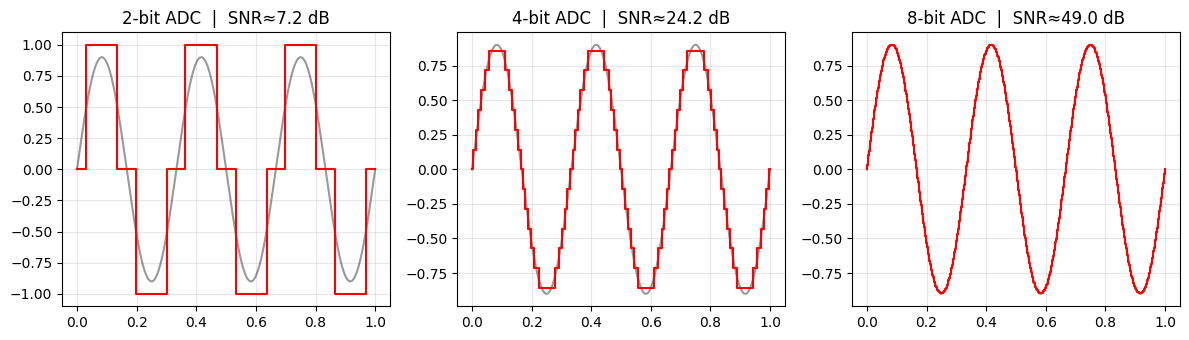

theory: SNR ~= 6.02*Nbits + 1.76 dB  -> ['2b:13.8dB', '4b:25.8dB', '8b:49.9dB']


In [6]:
# effect of ADC bit depth on the waveform and noise
def quantize(x, nbits, xmax=1.0):
    levels = 2**nbits
    q = np.round((x/xmax) * (levels/2 - 1)) / (levels/2 - 1) * xmax
    return np.clip(q, -xmax, xmax)

t = np.linspace(0, 1, 500)
x = 0.9*np.sin(2*np.pi*3*t)

plt.figure(figsize=(12,3.5))
for i, nb in enumerate([2, 4, 8]):
    xq = quantize(x, nb)
    noise = xq - x
    snr = 10*np.log10(np.mean(x**2)/np.mean(noise**2))
    plt.subplot(1,3,i+1)
    plt.plot(t, x, 'k', alpha=0.4)
    plt.step(t, xq, 'r', where='mid')
    plt.title(f"{nb}-bit ADC  |  SNR≈{snr:.1f} dB")
    plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("theory: SNR ~= 6.02*Nbits + 1.76 dB  ->",
      [f"{nb}b:{6.02*nb+1.76:.1f}dB" for nb in (2,4,8)])


<div dir="rtl" style="text-align:right">

## 4. الرجفة الزمنية (Clock Jitter)

لا يأخذ الـ ADC عيّناته في لحظات مثالية؛ هناك اهتزاز صغير في توقيت الساعة يُسمّى **jitter**. أثره يتفاقم كلما ارتفع تردد **دخل** الـ ADC — وهو تحدٍّ جوهري في الـ Direct RF Sampling حيث الدخل عند 2 GHz. حدّ نظري للـ SNR بسبب jitter بمقدار $\sigma_t$:

<div dir="ltr" style="text-align:left">

$$ \text{SNR}_{jitter} = -20 \log_{10}(2\pi f \sigma_t) $$

</div>

</div>

In [7]:
f_sig = 2e9   # signal frequency (2 GHz)
for jit in [1e-12, 100e-15, 10e-15]:   # 1 ps, 100 fs, 10 fs
    snr = -20*np.log10(2*np.pi*f_sig*jit)
    print(f"jitter σt = {jit*1e15:6.0f} fs  ->  SNR due to jitter ~= {snr:5.1f} dB")
print("\nTakeaway: at 2 GHz we need jitter on the order of tens of femtoseconds to keep quality high.")


jitter σt =   1000 fs  ->  SNR due to jitter ~=  38.0 dB
jitter σt =    100 fs  ->  SNR due to jitter ~=  58.0 dB
jitter σt =     10 fs  ->  SNR due to jitter ~=  78.0 dB

Takeaway: at 2 GHz we need jitter on the order of tens of femtoseconds to keep quality high.


<div dir="rtl" style="text-align:right">

## 5. الخلاصة

- الـ **sampling** يحوّل الإشارة المتصلة إلى عيّنات؛ وشرط **Nyquist** يحدّد الحدّ الأدنى (`fs > 2·BW` للإشارة النطاقية) وإلا حدث **aliasing**.
- **مستقبِل IF** يخلط الـ RF إلى IF منخفض بمكوّنات تناظرية ثم يأخذ عيّنات بطيئة؛ يعتمد على **مرشّحات IF** ويتجنّب الطيّ.
- **مستقبِل Direct RF Sampling** يأخذ عيّنات من الـ RF مباشرة و**يستغلّ الطيّ عمداً**؛ معدل العيّنات هو خطة الترددات، والمرشّح التمهيدي RF ضروري، والإنزال رقمي (DDC).
- محوّل ADC حقيقي يضيف **ضجيج تكميم** (≈6 dB لكل بِت) ويتأثر بالـ **jitter** خصوصاً عند دخل RF عالي التردد.

في المحاضرة القادمة نبني **المُرسِل المرجعي** لتوليد إشارة اختبار معروفة الإجابة.

</div>

<div dir="rtl" style="text-align:right">

---
### تمارين
1. غيّر `f0` و`fs_bad` في تجربة الـ aliasing وتحقّق من صيغة $f_{alias}$.
2. لمستقبِل IF: اختر LO يعطي IF = 70 MHz لقناة 2.0 GHz. ما التردد الصوري؟
3. لمستقبِل Direct RF عند `Fs = 1.5 GSPS`: إلى أي تردد تنطوي القناة العليا 2.045 GHz؟ وأي حاجب قد يسقط فوقها؟
4. كم بِتاً يحتاج الـ ADC ليعطي SNR ≥ 50 dB نظرياً؟

</div>